In [2]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, confusion_matrix, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from matplotlib import pyplot as plt
import numpy as np

In [3]:
# Cell 2: Load and Filter Dataset
df = pd.read_csv("5g_nidd.csv")

# Keep only HTTPFlood, UDPFlood, and SYNFlood
df = df[df['Attack Type'].isin(['HTTPFlood', 'UDPFlood', 'SYNFlood', 'ICMPFlood', 'Benign'])]

# Separate features and labels
X = df.drop(columns=['Attack Type']).values
y = df['Attack Type'].values


/var/folders/45/0lfy6jf14g3cptljv3x_x53r0000gn/T/ipykernel_2168/1873297042.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("5g_nidd.csv")


In [4]:
# X preprocessing
scaler = MinMaxScaler()

# Keep only columns with numeric dtype in X
float_cols = [i for i, col in enumerate(df.drop(columns=['Attack Type']).columns) if df[col].dtype != str and df[col].dtype != 'object']
X_numeric = X[:, float_cols]

X_scaled = scaler.fit_transform(X_numeric)
X_scaled = np.nan_to_num(X_scaled, nan=0.0)


In [5]:
# Calculate importance of features using Random Forest
from sklearn.ensemble import RandomForestClassifier

# Use the scaled features and binary labels
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

X_udp_only = X_scaled[y == 'UDPFlood']  # Use only UDPFlood for feature importance
y_udp_only = y[y == 'UDPFlood']
rf.fit(X_udp_only, y_udp_only)

importances = rf.feature_importances_

# Get feature names from df using float_cols
feature_names = df.drop(columns=['Attack Type']).columns[float_cols]

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Id': range(len(feature_names)),
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

# Keep only top 32 features by importance
top_features = feature_importance_df['Id'].iloc[:32].tolist()

print("Top 32 features:", top_features)
X_processed = X_scaled[:, top_features]

print(X_processed.shape)

    Id     Feature  Importance
0    0  Unnamed: 0         0.0
1    1         Seq         0.0
24  24     SrcLoad         0.0
25  25     DstLoad         0.0
26  26        Loss         0.0
27  27     SrcLoss         0.0
28  28     DstLoss         0.0
29  29       pLoss         0.0
30  30      SrcGap         0.0
31  31      DstGap         0.0
32  32        Rate         0.0
33  33     SrcRate         0.0
34  34     DstRate         0.0
35  35      SrcWin         0.0
36  36      DstWin         0.0
37  37        sVid         0.0
38  38        dVid         0.0
39  39  SrcTCPBase         0.0
40  40  DstTCPBase         0.0
41  41      TcpRtt         0.0
42  42      SynAck         0.0
23  23        Load         0.0
22  22  dMeanPktSz         0.0
21  21  sMeanPktSz         0.0
10  10        sTtl         0.0
2    2         Dur         0.0
3    3     RunTime         0.0
4    4        Mean         0.0
5    5         Sum         0.0
6    6         Min         0.0
7    7         Max         0.0
8    8  

In [6]:
# Y preprocessing
y_processed = np.where(y == 'Benign', 0, 1)

In [7]:
# Cell 4: Define the MLP Model
# 32 features
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


In [8]:
def meta_train_step(model, x_meta_train, y_meta_train, x_meta_test, y_meta_test, optimizer, alpha=0.5):
    loss_fn = nn.BCELoss()

    # Forward pass on meta-train
    y_pred_train = model(x_meta_train)
    loss_train = loss_fn(y_pred_train, y_meta_train)

    # Forward pass on meta-test
    y_pred_test = model(x_meta_test)
    loss_test = loss_fn(y_pred_test, y_meta_test)

    # Combined loss
    loss = alpha * loss_train + (1 - alpha) * loss_test

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


In [9]:
def normal_train_step(model, x_train, y_train, optimizer):
    loss_fn = nn.BCELoss()

    # Forward pass on meta-train
    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


In [11]:
# Get indices for each class in train
benign_index = np.where(y == 'Benign')[0]
udp_index = np.where(y == 'UDPFlood')[0]
http_index = np.where(y == 'HTTPFlood')[0]
syn_index = np.where(y == 'SYNFlood')[0]

print("Benign size:", len(benign_index))
print("UDPFlood size:", len(udp_index))
print("HTTPFlood size:", len(http_index))
print("SYNFlood size:", len(syn_index))

train_http_index = np.random.choice(http_index, int(0.8 * len(http_index)), replace=False)
test_http_index = np.setdiff1d(http_index, train_http_index)

train_syn_index = np.random.choice(syn_index, int(0.8 * len(syn_index)), replace=False)
test_syn_index = np.setdiff1d(syn_index, train_syn_index)


Benign size: 477737
UDPFlood size: 457340
HTTPFlood size: 140812
SYNFlood size: 9721


In [ ]:
# f1_scores = []
# f1_scores_std = []
# precisions = []
# precisions_std = []
# recalls = []
# recalls_std = []

# for len_meta_test in [1, 10, 100, 1000, 5000]:
#     repetition_f1_scores = []
#     repetition_precisions = []
#     repetition_recalls = []
#     print(f"Running for len_meta_test: {len_meta_test}")
#     for repetition in range(1):
#         # Shuffle indices for random sampling
#         rng = np.random.default_rng(seed=repetition)
#         rng.shuffle(benign_index)
#         rng.shuffle(udp_index)
#         rng.shuffle(train_http_index)
#         rng.shuffle(test_http_index)
#         rng.shuffle(train_syn_index)
#         rng.shuffle(test_syn_index)

#         print(f"Repetition {repetition + 1}/1")
#         kf = KFold(n_splits=5, shuffle=True, random_state=(repetition + 42))
#         fold_f1_scores = []
#         fold_precisions = []
#         fold_recalls = []

#         combined_index = np.concatenate([benign_index, udp_index])
#         for fold, (train, test) in enumerate(kf.split(combined_index)):
#             # Get indices for each class in train and test
#             train_index = combined_index[train]
#             test_index = combined_index[test]
#             rng.shuffle(train_index)
#             rng.shuffle(test_index)
            
#             train_benign_index = train_index[np.where(y_processed[train_index] == 0)[0]]
#             train_udp_index = train_index[np.where(y_processed[train_index] == 1)[0]]
#             test_benign_index = test_index[np.where(y_processed[test_index] == 0)[0]]
#             test_udp_index = test_index[np.where(y_processed[test_index] == 1)[0]]
            
#             # Split into 80% and 20%
#             n_train_benign_80 = int(0.8 * len(train_benign_index))
#             train_benign_80_index = train_benign_index[:n_train_benign_80]
#             train_benign_20_index = train_benign_index[n_train_benign_80:]
            
#             # Meta-train: all UDPFlood + 80% Benign: 500k of UDPFlood + 400k of Benign
#             meta_train_index = np.concatenate([train_udp_index, train_benign_80_index])
#             x_meta_train = torch.tensor(X_processed[meta_train_index], dtype=torch.float32)
#             y_meta_train = torch.tensor(y_processed[meta_train_index], dtype=torch.float32).unsqueeze(1)
            
#             # Meta-test: len_meta_test samples from HTTPFlood, SYNFlood + 20% Benign (100k Benign)
#             meta_test_index = np.concatenate([
#                 train_http_index[:len_meta_test], 
#                 train_syn_index[:len_meta_test], 
#                 train_benign_20_index
#             ])
#             x_meta_test = torch.tensor(X_processed[meta_test_index], dtype=torch.float32)
#             y_meta_test = torch.tensor(y_processed[meta_test_index], dtype=torch.float32).unsqueeze(1)

#             # Test set: 1000 samples from HTTPFlood, SYNFlood, UDPFlood and 3000 Benign
#             test_index = np.concatenate([
#                 test_http_index[:1000], 
#                 test_syn_index[:1000], 
#                 test_udp_index[:1000], 
#                 test_benign_index[:3000]
#             ])
#             x_test = torch.tensor(X_processed[test_index], dtype=torch.float32)
#             y_test = torch.tensor(y_processed[test_index], dtype=torch.float32).unsqueeze(1)

#             # Initialize model and training
#             model = MLP(X_processed.shape[1])
#             optimizer = optim.Adam(model.parameters(), lr=0.001)

#             # Training
#             for epoch in range(1000):
#                 loss = meta_train_step(model, x_meta_train, y_meta_train, x_meta_test, y_meta_test, optimizer)

#             # Evaluation
#             with torch.no_grad():
#                 y_pred = model(x_test).squeeze().round().numpy()
#                 score = f1_score(y_test.numpy(), y_pred)
#                 cm = confusion_matrix(y_test.numpy(), y_pred)
#                 precision = precision_score(y_test.numpy(), y_pred)
#                 recall = recall_score(y_test.numpy(), y_pred)

#                 fold_f1_scores.append(score)
#                 fold_precisions.append(precision)
#                 fold_recalls.append(recall)

#         repetition_f1_scores.append(np.mean(fold_f1_scores))
#         repetition_precisions.append(np.mean(fold_precisions))
#         repetition_recalls.append(np.mean(fold_recalls))

#     f1_scores.append(np.mean(repetition_f1_scores))
#     precisions.append(np.mean(repetition_precisions))
#     recalls.append(np.mean(repetition_recalls))

#     f1_scores_std.append(np.std(repetition_f1_scores))
#     precisions_std.append(np.std(repetition_precisions))
#     recalls_std.append(np.std(repetition_recalls))
    
#     print(f"F1 Score: {f1_scores[-1]:.4f} ± {f1_scores_std[-1]:.4f}")

In [ ]:
# # Visualization
# print("F1 Scores:")
# for i in range(len(f1_scores)):
#     print(f"{f1_scores[i]:.4f} ± {f1_scores_std[i]:.4f}")
    
# print("Precisions:")
# for i in range(len(precisions)):
#     print(f"{precisions[i]:.4f} ± {precisions_std[i]:.4f}")
    
# print("Recalls:")
# for i in range(len(recalls)):
#     print(f"{recalls[i]:.4f} ± {recalls_std[i]:.4f}")
    
# x = [1, 10, 100, 1000, 5000]

# plt.plot(x, precisions, marker='o', label='Precision')
# plt.plot(x, recalls, marker='s', label='Recall')
# plt.plot(x, f1_scores, marker='^', label='F1 Score')
# plt.xscale('log')
# plt.xlabel('Sample Size')
# plt.ylabel('Score')
# plt.title('Precision, Recall, and F1 Score vs Sample Size')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [ ]:
# f1_scores_udp = []
# f1_scores_std_udp = []
# precisions_udp = []
# precisions_std_udp = []
# recalls_udp = []
# recalls_std_udp = []

# f1_scores_udp_http = []
# f1_scores_std_udp_http = []
# precisions_udp_http = []
# precisions_std_udp_http = []
# recalls_udp_http = []
# recalls_std_udp_http = []

# f1_scores_udp_http_syn = []
# f1_scores_std_udp_http_syn = []
# precisions_udp_http_syn = []
# precisions_std_udp_http_syn = []
# recalls_udp_http_syn = []
# recalls_std_udp_http_syn = []

# # Experiment with different number of meta-test samples
# for len_meta_test in [1, 10, 100, 1000, 5000]:
#     repetition_f1_scores_udp = []
#     repetition_precisions_udp = []
#     repetition_recalls_udp = []

#     repetition_f1_scores_udp_http = []
#     repetition_precisions_udp_http = []
#     repetition_recalls_udp_http = []

#     repetition_f1_scores_udp_http_syn = []
#     repetition_precisions_udp_http_syn = []
#     repetition_recalls_udp_http_syn = []

#     print(f"Running for len_meta_test: {len_meta_test}")
#     for repetition in range(1):
#         print(f"Repetition {repetition + 1}/1")
#         kf = KFold(n_splits=5, shuffle=True, random_state=42)
        
#         # Shuffle indices for random sampling
#         rng = np.random.default_rng(seed=repetition)
#         rng.shuffle(benign_index)
#         rng.shuffle(udp_index)
#         rng.shuffle(train_http_index)
#         rng.shuffle(train_syn_index)
#         rng.shuffle(test_http_index)
#         rng.shuffle(test_syn_index)

#         fold_f1_scores_udp = []
#         fold_precisions_udp = []
#         fold_recalls_udp = []
        
#         fold_f1_scores_udp_http = []
#         fold_precisions_udp_http = []
#         fold_recalls_udp_http = []
        
#         fold_f1_scores_udp_http_syn = []
#         fold_precisions_udp_http_syn = []
#         fold_recalls_udp_http_syn = []

#         combined_index = np.concatenate([benign_index, udp_index])
#         for fold, (train, test) in enumerate(kf.split(combined_index)):
#             # Get indices for each class in train and test
#             train_index = combined_index[train]
#             test_index = combined_index[test]
#             rng.shuffle(train_index)
#             rng.shuffle(test_index)
            
#             train_benign_index = np.intersect1d(train_index, benign_index)
#             train_udp_index = np.intersect1d(train_index, udp_index)
#             test_benign_index = np.intersect1d(test_index, benign_index)
#             test_udp_index = np.intersect1d(test_index, udp_index)

#             # Split into 40%, 30% and 30%    
#             len_train_udp_40 = int(0.4 * len(train_udp_index))
#             len_train_udp_70 = int(0.7 * len(train_udp_index))
            
#             # Split into 40%, 15%, 15%, 15% and 15%    
#             len_train_benign_40 = int(0.4 * len(train_benign_index))
#             len_train_benign_55 = int(0.55 * len(train_benign_index))
#             len_train_benign_70 = int(0.7 * len(train_benign_index))
#             len_train_benign_85 = int(0.85 * len(train_benign_index))

#             # Initialize model and training
#             model = MLP(X_processed.shape[1])
#             optimizer = optim.Adam(model.parameters(), lr=0.001)
            
#             #--------------------------------- Training with UDP only ---------------------------------------#
#             # Train: 40% UDPFlood + 40% Benign
#             udp_train_index = np.concatenate([train_udp_index[:len_train_udp_40], train_benign_index[:len_train_benign_40]])
#             x_train = torch.tensor(X_processed[udp_train_index], dtype=torch.float32)
#             y_train = torch.tensor(y_processed[udp_train_index], dtype=torch.float32).unsqueeze(1)

#             # Training with UDP only
#             for epoch in range(1000):
#                 loss = normal_train_step(model, x_train, y_train, optimizer)

#             # Evaluation with UDP only
#             with torch.no_grad():
#                 udp_test_index = np.concatenate([test_benign_index[:1000], test_udp_index[:1000]])
#                 x_test = torch.tensor(X_processed[udp_test_index], dtype=torch.float32)
#                 y_test = torch.tensor(y_processed[udp_test_index], dtype=torch.float32).unsqueeze(1)

#                 y_pred = model(x_test).squeeze().round().numpy()
#                 score = f1_score(y_test.numpy(), y_pred)
#                 precision = precision_score(y_test.numpy(), y_pred, zero_division=0)
#                 recall = recall_score(y_test.numpy(), y_pred)

#                 fold_f1_scores_udp.append(score)
#                 fold_precisions_udp.append(precision)
#                 fold_recalls_udp.append(recall)
                

#             #--------------------------------- Training with UDP and HTTP ---------------------------------------#
#             # Meta-train: 30% UDPFlood + 15% Benign
#             udp_http_meta_train_index = np.concatenate([train_udp_index[len_train_udp_40:len_train_udp_70], train_benign_index[len_train_benign_40:len_train_benign_55]])
#             x_meta_train = torch.tensor(X_processed[udp_http_meta_train_index], dtype=torch.float32)
#             y_meta_train = torch.tensor(y_processed[udp_http_meta_train_index], dtype=torch.float32).unsqueeze(1)

#             # Meta-test: len_meta_test samples from HTTPFlood and 15% Benign
#             udp_http_meta_test_index = np.concatenate([
#                 train_http_index[:len_meta_test], 
#                 train_benign_index[len_train_benign_55:len_train_benign_70]
#             ])
#             x_meta_test = torch.tensor(X_processed[udp_http_meta_test_index], dtype=torch.float32)
#             y_meta_test = torch.tensor(y_processed[udp_http_meta_test_index], dtype=torch.float32).unsqueeze(1)
            
#             for epoch in range(1000):
#                 loss = meta_train_step(model, x_meta_train, y_meta_train, x_meta_test, y_meta_test, optimizer)
                
#             # Evaluation
#             with torch.no_grad():
#                 udp_http_test_index = np.concatenate([test_benign_index[:2000], test_udp_index[:1000], test_http_index[:1000]])
#                 x_test= torch.tensor(X_processed[udp_http_test_index], dtype=torch.float32)
#                 y_test = torch.tensor(y_processed[udp_http_test_index], dtype=torch.float32).unsqueeze(1)

#                 y_pred = model(x_test).squeeze().round().numpy()
#                 score = f1_score(y_test.numpy(), y_pred)
#                 precision = precision_score(y_test.numpy(), y_pred, zero_division=0)
#                 recall = recall_score(y_test.numpy(), y_pred)

#                 fold_f1_scores_udp_http.append(score)
#                 fold_precisions_udp_http.append(precision)
#                 fold_recalls_udp_http.append(recall)


#             #--------------------------------- Training with UDP and SYN ---------------------------------------#
#             # Meta-train: 30% UDPFlood + 15% Benign
#             meta_train_index = np.concatenate([train_udp_index[len_train_udp_70:], train_benign_index[len_train_benign_70:len_train_benign_85]])    
#             x_meta_train = torch.tensor(X_processed[meta_train_index], dtype=torch.float32)
#             y_meta_train = torch.tensor(y_processed[meta_train_index], dtype=torch.float32).unsqueeze(1)

#             # Meta-test: len_meta_test samples from SYNFlood and 15% Benign
#             meta_test_index = np.concatenate([
#                 train_syn_index[:len_meta_test], 
#                 train_benign_index[len_train_benign_85:]
#             ])
#             x_meta_test = torch.tensor(X_processed[meta_test_index], dtype=torch.float32)
#             y_meta_test = torch.tensor(y_processed[meta_test_index], dtype=torch.float32).unsqueeze(1)

#             # Training
#             for epoch in range(1000):
#                 loss = meta_train_step(model, x_meta_train, y_meta_train, x_meta_test, y_meta_test, optimizer)

#             # Evaluation
#             with torch.no_grad():
#                 udp_http_syn_test_index = np.concatenate([test_benign_index[:3000], test_udp_index[:1000], test_http_index[:1000], test_syn_index[:1000]])
#                 x_test= torch.tensor(X_processed[udp_http_syn_test_index], dtype=torch.float32)
#                 y_test = torch.tensor(y_processed[udp_http_syn_test_index], dtype=torch.float32).unsqueeze(1)

#                 y_pred = model(x_test).squeeze().round().numpy()
#                 score = f1_score(y_test.numpy(), y_pred)
#                 precision = precision_score(y_test.numpy(), y_pred, zero_division=0)
#                 recall = recall_score(y_test.numpy(), y_pred)

#                 fold_f1_scores_udp_http_syn.append(score)
#                 fold_precisions_udp_http_syn.append(precision)
#                 fold_recalls_udp_http_syn.append(recall)

#         repetition_f1_scores_udp.append(np.mean(fold_f1_scores_udp))
#         repetition_precisions_udp.append(np.mean(fold_precisions_udp))
#         repetition_recalls_udp.append(np.mean(fold_recalls_udp))

#         repetition_f1_scores_udp_http.append(np.mean(fold_f1_scores_udp_http))
#         repetition_precisions_udp_http.append(np.mean(fold_precisions_udp_http))
#         repetition_recalls_udp_http.append(np.mean(fold_recalls_udp_http))

#         repetition_f1_scores_udp_http_syn.append(np.mean(fold_f1_scores_udp_http_syn))
#         repetition_precisions_udp_http_syn.append(np.mean(fold_precisions_udp_http_syn))
#         repetition_recalls_udp_http_syn.append(np.mean(fold_recalls_udp_http_syn))

#     f1_scores_udp.append(np.mean(repetition_f1_scores_udp))
#     precisions_udp.append(np.mean(repetition_precisions_udp))
#     recalls_udp.append(np.mean(repetition_recalls_udp))
#     f1_scores_std_udp.append(np.std(repetition_f1_scores_udp))
#     precisions_std_udp.append(np.std(repetition_precisions_udp))
#     recalls_std_udp.append(np.std(repetition_recalls_udp))

#     f1_scores_udp_http.append(np.mean(repetition_f1_scores_udp_http))
#     precisions_udp_http.append(np.mean(repetition_precisions_udp_http))
#     recalls_udp_http.append(np.mean(repetition_recalls_udp_http))
#     f1_scores_std_udp_http.append(np.std(repetition_f1_scores_udp_http))
#     precisions_std_udp_http.append(np.std(repetition_precisions_udp_http))
#     recalls_std_udp_http.append(np.std(repetition_recalls_udp_http))

#     f1_scores_udp_http_syn.append(np.mean(repetition_f1_scores_udp_http_syn))
#     precisions_udp_http_syn.append(np.mean(repetition_precisions_udp_http_syn))
#     recalls_udp_http_syn.append(np.mean(repetition_recalls_udp_http_syn))
#     f1_scores_std_udp_http_syn.append(np.std(repetition_f1_scores_udp_http_syn))
#     precisions_std_udp_http_syn.append(np.std(repetition_precisions_udp_http_syn))
#     recalls_std_udp_http_syn.append(np.std(repetition_recalls_udp_http_syn))
    
#     print(f"F1 Score (UDP): {f1_scores_udp[-1]:.4f} ± {f1_scores_std_udp[-1]:.4f}")
#     print(f"F1 Score (UDP + HTTP): {f1_scores_udp_http[-1]:.4f} ± {f1_scores_std_udp_http[-1]:.4f}")
#     print(f"F1 Score (UDP + HTTP + SYN): {f1_scores_udp_http_syn[-1]:.4f} ± {f1_scores_std_udp_http_syn[-1]:.4f}")


In [ ]:
# print("Results for UDPFlood only:")
# print("F1 Scores:")
# for i in range(len(f1_scores_udp)):
#     print(f"{f1_scores_udp[i]:.4f} ± {f1_scores_std_udp[i]:.4f}")

# print("Precisions:")
# for i in range(len(precisions_udp)):
#     print(f"{precisions_udp[i]:.4f} ± {precisions_std_udp[i]:.4f}")

# print("Recalls:")
# for i in range(len(recalls_udp)):
#     print(f"{recalls_udp[i]:.4f} ± {recalls_std_udp[i]:.4f}")

# print("Results for UDPFlood + HTTPFlood:")
# print("F1 Scores:")
# for i in range(len(f1_scores_udp_http)):
#     print(f"{f1_scores_udp_http[i]:.4f} ± {f1_scores_std_udp_http[i]:.4f}")

# print("Precisions:")
# for i in range(len(precisions_udp_http)):
#     print(f"{precisions_udp_http[i]:.4f} ± {precisions_std_udp_http[i]:.4f}")

# print("Recalls:")
# for i in range(len(recalls_udp_http)):
#     print(f"{recalls_udp_http[i]:.4f} ± {recalls_std_udp_http[i]:.4f}")

# print("Results for UDPFlood + HTTPFlood + SYNFlood:")
# print("F1 Scores:")
# for i in range(len(f1_scores_udp_http_syn)):
#     print(f"{f1_scores_udp_http_syn[i]:.4f} ± {f1_scores_std_udp_http_syn[i]:.4f}")

# print("Precisions:")
# for i in range(len(precisions_udp_http_syn)):
#     print(f"{precisions_udp_http_syn[i]:.4f} ± {precisions_std_udp_http_syn[i]:.4f}")

# print("Recalls:")
# for i in range(len(recalls_udp_http_syn)):
#     print(f"{recalls_udp_http_syn[i]:.4f} ± {recalls_std_udp_http_syn[i]:.4f}")

# x = [1, 10, 100, 1000, 5000]

# plt.plot(x, precisions_udp, marker='o', label='Precision')
# plt.plot(x, recalls_udp, marker='s', label='Recall')
# plt.plot(x, f1_scores_udp, marker='^', label='F1 Score')
# plt.xscale('log')
# plt.xlabel('Sample Size')
# plt.ylabel('Score')
# plt.title('Precision, Recall, and F1 Score of M1 model (UDP only) vs Sample Size')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.plot(x, precisions_udp_http, marker='o', label='Precision')
# plt.plot(x, recalls_udp_http, marker='s', label='Recall')
# plt.plot(x, f1_scores_udp_http, marker='^', label='F1 Score')
# plt.xscale('log')
# plt.xlabel('Sample Size')
# plt.ylabel('Score')
# plt.title('Precision, Recall, and F1 Score of M2 model (UDP + HTTP) vs Sample Size')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.plot(x, precisions_udp_http_syn, marker='o', label='Precision')
# plt.plot(x, recalls_udp_http_syn, marker='s', label='Recall')
# plt.plot(x, f1_scores_udp_http_syn, marker='^', label='F1 Score')
# plt.xscale('log')
# plt.xlabel('Sample Size')
# plt.ylabel('Score')
# plt.title('Precision, Recall, and F1 Score of M3 model (UDP + HTTP + SYN) vs Sample Size')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [ ]:
# f1_scores = []
# f1_scores_std = []
# precisions = []
# precisions_std = []
# recalls = []
# recalls_std = []

# # Experiment with different alphas
# for alpha in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
#     repetition_f1_scores = []
#     repetition_precisions = []
#     repetition_recalls = []
#     len_meta_test = 5000
#     print(f"Running for alpha: {alpha}")
#     for repetition in range(1):
#         # Shuffle indices for random sampling
#         rng = np.random.default_rng(seed=repetition)
#         rng.shuffle(benign_index)
#         rng.shuffle(udp_index)
#         rng.shuffle(train_http_index)
#         rng.shuffle(test_http_index)
#         rng.shuffle(train_syn_index)
#         rng.shuffle(test_syn_index)

#         print(f"Repetition {repetition + 1}/1")
#         kf = KFold(n_splits=5, shuffle=True, random_state=42)
#         fold_f1_scores = []
#         fold_precisions = []
#         fold_recalls = []

#         combined_index = np.concatenate([benign_index, udp_index])
#         for fold, (train, test) in enumerate(kf.split(combined_index)):
#             # Get indices for each class in train and test
#             train_index = combined_index[train]
#             test_index = combined_index[test]
#             rng.shuffle(train_index)
#             rng.shuffle(test_index)
            
#             train_benign_index = train_index[np.where(y_processed[train_index] == 0)[0]]
#             train_udp_index = train_index[np.where(y_processed[train_index] == 1)[0]]
#             test_benign_index = test_index[np.where(y_processed[test_index] == 0)[0]]
#             test_udp_index = test_index[np.where(y_processed[test_index] == 1)[0]]
            
#             # Split into 80% and 20%
#             n_train_benign_80 = int(0.8 * len(train_benign_index))
#             train_benign_80_index = train_benign_index[:n_train_benign_80]
#             train_benign_20_index = train_benign_index[n_train_benign_80:]
            
#             # Meta-train: all UDPFlood + 80% Benign
#             meta_train_index = np.concatenate([train_udp_index, train_benign_80_index])
#             x_meta_train = torch.tensor(X_processed[meta_train_index], dtype=torch.float32)
#             y_meta_train = torch.tensor(y_processed[meta_train_index], dtype=torch.float32).unsqueeze(1)
            
#             # Meta-test: len_meta_test samples from HTTPFlood, SYNFlood + 20% Benign
#             meta_test_index = np.concatenate([
#                 train_http_index[:len_meta_test], 
#                 train_syn_index[:len_meta_test], 
#                 train_benign_20_index
#             ])
#             x_meta_test = torch.tensor(X_processed[meta_test_index], dtype=torch.float32)
#             y_meta_test = torch.tensor(y_processed[meta_test_index], dtype=torch.float32).unsqueeze(1)

#             # Test set: 1000 samples from HTTPFlood, SYNFlood, UDPFlood and 4000 Benign
#             test_index = np.concatenate([
#                 test_http_index[:1000], 
#                 test_syn_index[:1000], 
#                 test_udp_index[:1000], 
#                 test_benign_index[:3000]
#             ])
#             x_test = torch.tensor(X_processed[test_index], dtype=torch.float32)
#             y_test = torch.tensor(y_processed[test_index], dtype=torch.float32).unsqueeze(1)

#             # Initialize model and training
#             model = MLP(X_processed.shape[1])
#             optimizer = optim.Adam(model.parameters(), lr=0.001)

#             # Training
#             for epoch in range(1000):
#                 loss = meta_train_step(model, x_meta_train, y_meta_train, x_meta_test, y_meta_test, optimizer, alpha=alpha)

#             # Evaluation
#             with torch.no_grad():
#                 y_pred = model(x_test).squeeze().round().numpy()
#                 score = f1_score(y_test.numpy(), y_pred)
#                 cm = confusion_matrix(y_test.numpy(), y_pred)
#                 precision = precision_score(y_test.numpy(), y_pred)
#                 recall = recall_score(y_test.numpy(), y_pred)

#                 fold_f1_scores.append(score)
#                 fold_precisions.append(precision)
#                 fold_recalls.append(recall)

#         repetition_f1_scores.append(np.mean(fold_f1_scores))
#         repetition_precisions.append(np.mean(fold_precisions))
#         repetition_recalls.append(np.mean(fold_recalls))

#     f1_scores.append(np.mean(repetition_f1_scores))
#     precisions.append(np.mean(repetition_precisions))
#     recalls.append(np.mean(repetition_recalls))

#     f1_scores_std.append(np.std(repetition_f1_scores))
#     precisions_std.append(np.std(repetition_precisions))
#     recalls_std.append(np.std(repetition_recalls))
    
#     print(f"F1 Score: {f1_scores[-1]:.4f} ± {f1_scores_std[-1]:.4f}")

In [ ]:
# # Visualization
# print("F1 Scores:")
# for i in range(len(f1_scores)):
#     print(f"{f1_scores[i]:.4f} ± {f1_scores_std[i]:.4f}")
    
# print("Precisions:")
# for i in range(len(precisions)):
#     print(f"{precisions[i]:.4f} ± {precisions_std[i]:.4f}")
    
# print("Recalls:")
# for i in range(len(recalls)):
#     print(f"{recalls[i]:.4f} ± {recalls_std[i]:.4f}")
    
# x = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# plt.plot(x, precisions, marker='o', label='Precision')
# plt.plot(x, recalls, marker='s', label='Recall')
# plt.plot(x, f1_scores, marker='^', label='F1 Score')
# plt.xlabel('Alpha')
# plt.ylabel('Score')
# plt.title('Precision, Recall, and F1 Score vs Alpha')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [ ]:
# benign_index = np.where(y == 'Benign')[0]
# udp_index = np.where(y == 'UDPFlood')[0]
# print(f"Comaparing UDPFlood dataset with benign dataset: {len(udp_index) / len(benign_index) * 100:.2f}%")

# # Keep only UDPFlood and Benign for folding
# number_udp_samples = [len(benign_index) // 100 * i for i in range(1, 6)]
# print(f"Number of UDPFlood samples: {number_udp_samples}")

# f1_scores = []
# f1_scores_std = []
# precisions = []
# precisions_std = []
# recalls = []
# recalls_std = []

# for number_samples in number_udp_samples:
#     repetition_f1_scores = []
#     repetition_precisions = []
#     repetition_recalls = []
#     print(f"Running for number of UDPFlood samples: {number_samples}")
    
#     # Take a random sample of UDPFlood samples from X_udp_only_processed
#     rng = np.random.default_rng(seed=number_samples)
#     udp_sample_index = rng.choice(udp_index, size=number_samples, replace=False)
#     X_processed_sample = X_processed[np.concatenate([udp_sample_index, benign_index])]
#     y_processed_sample = y_processed[np.concatenate([udp_sample_index, benign_index])]

#     for repetition in range(1):
#         print(f"Repetition {repetition + 1}/1")
#         kf = KFold(n_splits=5, shuffle=True, random_state=42)
#         fold_f1_scores = []
#         fold_precisions = []
#         fold_recalls = []
        
#         for fold, (train_index, test_index) in enumerate(kf.split(X_processed_sample)):
#             # Train set: 
#             x_train = torch.tensor(X_processed[train_index], dtype=torch.float32)
#             y_train = torch.tensor(y_processed[train_index], dtype=torch.float32).unsqueeze(1)

#             # Evaluation set:
#             x_test = torch.tensor(X_processed[test_index], dtype=torch.float32)
#             y_test = torch.tensor(y_processed[test_index], dtype=torch.float32).unsqueeze(1)

#             # Initialize model and training
#             model = MLP(X_processed.shape[1])
#             optimizer = optim.Adam(model.parameters(), lr=0.001)

#             # Training
#             for epoch in range(1000):
#                 loss = normal_train_step(model, x_train, y_train, optimizer)

#             # Evaluation
#             with torch.no_grad():
#                 y_pred = model(x_test).squeeze().round().numpy()
#                 score = f1_score(y_test.numpy(), y_pred)
#                 cm = confusion_matrix(y_test.numpy(), y_pred)
#                 precision = precision_score(y_test.numpy(), y_pred)
#                 recall = recall_score(y_test.numpy(), y_pred)

#                 fold_f1_scores.append(score)
#                 fold_precisions.append(precision)
#                 fold_recalls.append(recall)

#         repetition_f1_scores.append(np.mean(fold_f1_scores))
#         repetition_precisions.append(np.mean(fold_precisions))
#         repetition_recalls.append(np.mean(fold_recalls))

#     f1_scores.append(np.mean(repetition_f1_scores))
#     precisions.append(np.mean(repetition_precisions))
#     recalls.append(np.mean(repetition_recalls))

#     f1_scores_std.append(np.std(repetition_f1_scores))
#     precisions_std.append(np.std(repetition_precisions))
#     recalls_std.append(np.std(repetition_recalls))

In [ ]:
# print("F1 Scores:")
# for i in range(len(f1_scores)):
#     print(f"{f1_scores[i]:.4f} ± {f1_scores_std[i]:.4f}")
    
# print("Precisions:")
# for i in range(len(precisions)):
#     print(f"{precisions[i]:.4f} ± {precisions_std[i]:.4f}")
    
# print("Recalls:")
# for i in range(len(recalls)):
#     print(f"{recalls[i]:.4f} ± {recalls_std[i]:.4f}")
    
# x = number_udp_samples

# plt.plot(x, precisions, marker='o', label='Precision')
# plt.plot(x, recalls, marker='s', label='Recall')
# plt.plot(x, f1_scores, marker='^', label='F1 Score')
# plt.xlabel('Sample Size of UDPFlood')
# plt.ylabel('Score')
# plt.title('Precision, Recall, and F1 Score vs Sample Size of UDPFlood')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [11]:
# Keep only UDPFlood and Benign for folding
number_udp_samples = [len(benign_index) // 100 * i for i in range(1, 6)]
print(f"Number of UDPFlood samples: {number_udp_samples}")

samples = number_udp_samples[0]
rng = np.random.default_rng(seed=samples)
udp_index = np.where(y == 'UDPFlood')[0]
random_selected_udp_index = rng.choice(udp_index, size=samples, replace=False)
print(len(random_selected_udp_index), "samples of UDPFlood selected.")

# Update udp_index to the selected samples
udp_index = random_selected_udp_index

Number of UDPFlood samples: [4777, 9554, 14331, 19108, 23885]
4777 samples of UDPFlood selected.


In [13]:
f1_scores = []
f1_scores_std = []
precisions = []
precisions_std = []
recalls = []
recalls_std = []

# Experiment with different number of meta-test samples
for len_meta_test in [0]:
    
    # Shuffle indices for random sampling
    rng = np.random.default_rng(seed=len_meta_test)
    rng.shuffle(benign_index)
    rng.shuffle(udp_index)
    rng.shuffle(train_http_index)
    rng.shuffle(test_http_index)
    rng.shuffle(train_syn_index)
    rng.shuffle(test_syn_index)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_f1_scores = []
    fold_precisions = []
    fold_recalls = []

    combined_index = np.concatenate([benign_index, udp_index])
    print(len(combined_index), "samples in combined index.")
    for fold, (train, test) in enumerate(kf.split(combined_index)):
        # Get indices for each class in train and test
        train_index = combined_index[train]
        test_index = combined_index[test]
        rng.shuffle(train_index)
        rng.shuffle(test_index)
        
        x_train = torch.tensor(X_processed[train_index], dtype=torch.float32)
        y_train = torch.tensor(y_processed[train_index], dtype=torch.float32).unsqueeze(1)
        print("y_train == 0:", (y_train == 0).sum().item(), "y_train == 1:", (y_train == 1).sum().item())
        
        x_test = torch.tensor(X_processed[test_index], dtype=torch.float32)
        y_test = torch.tensor(y_processed[test_index], dtype=torch.float32).unsqueeze(1)
        print("y_test == 0:", (y_test == 0).sum().item(), "y_test == 1:", (y_test == 1).sum().item())

        # Initialize model and training
        model = MLP(X_processed.shape[1])
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # Training
        for epoch in range(1000):
            loss = normal_train_step(model, x_train, y_train, optimizer)

        # Evaluation
        with torch.no_grad():
            y_pred = model(x_test).squeeze().round().numpy()
            score = f1_score(y_test.numpy(), y_pred)
            cm = confusion_matrix(y_test.numpy(), y_pred)
            precision = precision_score(y_test.numpy(), y_pred)
            recall = recall_score(y_test.numpy(), y_pred)

            fold_f1_scores.append(score)
            fold_precisions.append(precision)
            fold_recalls.append(recall)

    f1_scores.append(np.mean(fold_f1_scores))
    precisions.append(np.mean(fold_precisions))
    recalls.append(np.mean(fold_recalls))

    f1_scores_std.append(np.std(fold_f1_scores))
    precisions_std.append(np.std(fold_precisions))
    recalls_std.append(np.std(fold_recalls))

    print(f"F1 Score: {f1_scores[-1]:.4f} ± {f1_scores_std[-1]:.4f}")

482514 samples in combined index.
y_train == 0: 382150 y_train == 1: 3861
y_test == 0: 95587 y_test == 1: 916
y_train == 0: 382186 y_train == 1: 3825
y_test == 0: 95551 y_test == 1: 952
y_train == 0: 382171 y_train == 1: 3840
y_test == 0: 95566 y_test == 1: 937
y_train == 0: 382184 y_train == 1: 3827
y_test == 0: 95553 y_test == 1: 950
y_train == 0: 382257 y_train == 1: 3755
y_test == 0: 95480 y_test == 1: 1022
F1 Score: 0.9640 ± 0.0096


In [16]:
f1_scores = []
f1_scores_std = []
precisions = []
precisions_std = []
recalls = []
recalls_std = []

# Experiment with different number of meta-test samples
for len_meta_test in [0, 1, 10, 100, 1000, 5000]:
    print(f"Running for len_meta_test: {len_meta_test}")
    
    # Shuffle indices for random sampling
    rng = np.random.default_rng(seed=len_meta_test)
    rng.shuffle(benign_index)
    rng.shuffle(udp_index)
    rng.shuffle(train_http_index)
    rng.shuffle(test_http_index)
    rng.shuffle(train_syn_index)
    rng.shuffle(test_syn_index)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_f1_scores = []
    fold_precisions = []
    fold_recalls = []

    combined_index = np.concatenate([benign_index, udp_index])
    print(len(combined_index), "samples in combined index.")
    for fold, (train, test) in enumerate(kf.split(combined_index)):
        # Get indices for each class in train and test
        train_index = combined_index[train]
        test_index = combined_index[test]
        rng.shuffle(train_index)
        rng.shuffle(test_index)
        
        train_benign_index = train_index[np.where(y_processed[train_index] == 0)[0]]
        train_udp_index = train_index[np.where(y_processed[train_index] == 1)[0]]
        test_benign_index = test_index[np.where(y_processed[test_index] == 0)[0]]
        test_udp_index = test_index[np.where(y_processed[test_index] == 1)[0]]
        
        # Split into 80% and 20%
        n_train_benign_80 = int(0.8 * len(train_benign_index))
        train_benign_80_index = train_benign_index[:n_train_benign_80]
        train_benign_20_index = train_benign_index[n_train_benign_80:]
        
        # Meta-train: all UDPFlood + 80% Benign
        meta_train_index = np.concatenate([train_udp_index, train_benign_80_index])
        x_meta_train = torch.tensor(X_processed[meta_train_index], dtype=torch.float32)
        y_meta_train = torch.tensor(y_processed[meta_train_index], dtype=torch.float32).unsqueeze(1)
        print("y_meta_train == 0:", (y_meta_train == 0).sum().item(), "y_meta_train == 1:", (y_meta_train == 1).sum().item())
        
        # Meta-test: len_meta_test samples from HTTPFlood + 20% Benign
        meta_test_index = np.concatenate([
            train_http_index[:len_meta_test], 
            train_benign_20_index
        ])
        x_meta_test = torch.tensor(X_processed[meta_test_index], dtype=torch.float32)
        y_meta_test = torch.tensor(y_processed[meta_test_index], dtype=torch.float32).unsqueeze(1)
        print("y_meta_test == 0:", (y_meta_test == 0).sum().item(), "y_meta_test == 1:", (y_meta_test == 1).sum().item())
        
        # Test set: 1000 samples from HTTPFlood, UDPFlood and 3000 Benign
        test_index = np.concatenate([
            test_udp_index[:1000], 
            test_syn_index[:1000],
            test_benign_index[:2000]
        ])
        x_test = torch.tensor(X_processed[test_index], dtype=torch.float32)
        y_test = torch.tensor(y_processed[test_index], dtype=torch.float32).unsqueeze(1)
        print("y_test == 0:", (y_test == 0).sum().item(), "y_test == 1:", (y_test == 1).sum().item())

        # Initialize model and training
        model = MLP(X_processed.shape[1])
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # Training
        for epoch in range(1000):
            loss = meta_train_step(model, x_meta_train, y_meta_train, x_meta_test, y_meta_test, optimizer, alpha=0.5)

        # Evaluation
        with torch.no_grad():
            y_pred = model(x_test).squeeze().round().numpy()
            score = f1_score(y_test.numpy(), y_pred)
            cm = confusion_matrix(y_test.numpy(), y_pred)
            precision = precision_score(y_test.numpy(), y_pred)
            recall = recall_score(y_test.numpy(), y_pred)

            fold_f1_scores.append(score)
            fold_precisions.append(precision)
            fold_recalls.append(recall)

    f1_scores.append(np.mean(fold_f1_scores))
    precisions.append(np.mean(fold_precisions))
    recalls.append(np.mean(fold_recalls))

    f1_scores_std.append(np.std(fold_f1_scores))
    precisions_std.append(np.std(fold_precisions))
    recalls_std.append(np.std(fold_recalls))

    print(f"F1 Score: {f1_scores[-1]:.4f} ± {f1_scores_std[-1]:.4f}")

Running for len_meta_test: 0
482514 samples in combined index.
y_meta_train == 0: 305720 y_meta_train == 1: 3861
y_meta_test == 0: 76430 y_meta_test == 1: 0
y_test == 0: 2000 y_test == 1: 1916
y_meta_train == 0: 305748 y_meta_train == 1: 3825
y_meta_test == 0: 76438 y_meta_test == 1: 0
y_test == 0: 2000 y_test == 1: 1952
y_meta_train == 0: 305736 y_meta_train == 1: 3840
y_meta_test == 0: 76435 y_meta_test == 1: 0
y_test == 0: 2000 y_test == 1: 1937
y_meta_train == 0: 305747 y_meta_train == 1: 3827
y_meta_test == 0: 76437 y_meta_test == 1: 0
y_test == 0: 2000 y_test == 1: 1950
y_meta_train == 0: 305805 y_meta_train == 1: 3755
y_meta_test == 0: 76452 y_meta_test == 1: 0
y_test == 0: 2000 y_test == 1: 2000
F1 Score: 0.5989 ± 0.0246
Running for len_meta_test: 1
482514 samples in combined index.
y_meta_train == 0: 305720 y_meta_train == 1: 3861
y_meta_test == 0: 76430 y_meta_test == 1: 1
y_test == 0: 2000 y_test == 1: 1916
y_meta_train == 0: 305748 y_meta_train == 1: 3825
y_meta_test == 0: 

/Users/minhthienlongvo/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


y_meta_train == 0: 305805 y_meta_train == 1: 3755
y_meta_test == 0: 76452 y_meta_test == 1: 1
y_test == 0: 2000 y_test == 1: 2000
F1 Score: 0.4834 ± 0.2422
Running for len_meta_test: 10
482514 samples in combined index.
y_meta_train == 0: 305720 y_meta_train == 1: 3861
y_meta_test == 0: 76430 y_meta_test == 1: 10
y_test == 0: 2000 y_test == 1: 1916
y_meta_train == 0: 305748 y_meta_train == 1: 3825
y_meta_test == 0: 76438 y_meta_test == 1: 10
y_test == 0: 2000 y_test == 1: 1952
y_meta_train == 0: 305736 y_meta_train == 1: 3840
y_meta_test == 0: 76435 y_meta_test == 1: 10
y_test == 0: 2000 y_test == 1: 1937
y_meta_train == 0: 305747 y_meta_train == 1: 3827
y_meta_test == 0: 76437 y_meta_test == 1: 10
y_test == 0: 2000 y_test == 1: 1950
y_meta_train == 0: 305805 y_meta_train == 1: 3755
y_meta_test == 0: 76452 y_meta_test == 1: 10
y_test == 0: 2000 y_test == 1: 2000
F1 Score: 0.6231 ± 0.0360
Running for len_meta_test: 100
482514 samples in combined index.
y_meta_train == 0: 305720 y_meta_t

F1 Scores:
0.5989 ± 0.0246
0.4834 ± 0.2422
0.6231 ± 0.0360
0.7214 ± 0.0366
0.8918 ± 0.0091
0.9177 ± 0.0109
Precisions:
0.9991 ± 0.0008
0.8000 ± 0.4000
1.0000 ± 0.0000
0.9997 ± 0.0004
0.9992 ± 0.0005
0.9992 ± 0.0005
Recalls:
0.4281 ± 0.0251
0.3465 ± 0.1739
0.4535 ± 0.0367
0.5656 ± 0.0451
0.8054 ± 0.0149
0.8486 ± 0.0187


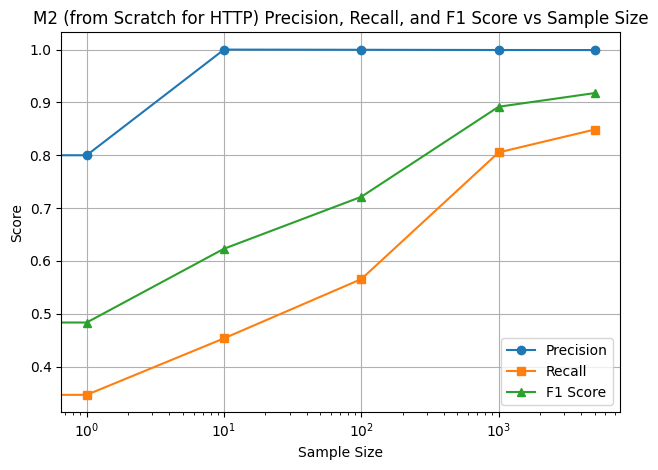

In [17]:
# Visualization
print("F1 Scores:")
for i in range(len(f1_scores)):
    print(f"{f1_scores[i]:.4f} ± {f1_scores_std[i]:.4f}")
    
print("Precisions:")
for i in range(len(precisions)):
    print(f"{precisions[i]:.4f} ± {precisions_std[i]:.4f}")
    
print("Recalls:")
for i in range(len(recalls)):
    print(f"{recalls[i]:.4f} ± {recalls_std[i]:.4f}")
    
x = [0, 1, 10, 100, 1000, 5000]

plt.plot(x, precisions, marker='o', label='Precision')
plt.plot(x, recalls, marker='s', label='Recall')
plt.plot(x, f1_scores, marker='^', label='F1 Score')
plt.xscale('log')
plt.xlabel('Sample Size')
plt.ylabel('Score')
plt.title('M2 (from Scratch for HTTP) Precision, Recall, and F1 Score vs Sample Size')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
f1_scores = []
f1_scores_std = []
precisions = []
precisions_std = []
recalls = []
recalls_std = []

# Experiment with different number of meta-test samples
for len_meta_test in [0, 1, 10, 100, 1000, 5000]:
    print(f"Running for len_meta_test: {len_meta_test}")
    
    # Shuffle indices for random sampling
    rng = np.random.default_rng(seed=len_meta_test)
    rng.shuffle(benign_index)
    rng.shuffle(udp_index)
    rng.shuffle(train_http_index)
    rng.shuffle(test_http_index)
    rng.shuffle(train_syn_index)
    rng.shuffle(test_syn_index)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_f1_scores = []
    fold_precisions = []
    fold_recalls = []

    combined_index = np.concatenate([benign_index, udp_index])
    print(len(combined_index), "samples in combined index.")
    for fold, (train, test) in enumerate(kf.split(combined_index)):
        # Get indices for each class in train and test
        train_index = combined_index[train]
        test_index = combined_index[test]
        rng.shuffle(train_index)
        rng.shuffle(test_index)
        
        train_benign_index = train_index[np.where(y_processed[train_index] == 0)[0]]
        train_udp_index = train_index[np.where(y_processed[train_index] == 1)[0]]
        test_benign_index = test_index[np.where(y_processed[test_index] == 0)[0]]
        test_udp_index = test_index[np.where(y_processed[test_index] == 1)[0]]
        
        # Split into 80% and 20%
        n_train_benign_80 = int(0.8 * len(train_benign_index))
        train_benign_80_index = train_benign_index[:n_train_benign_80]
        train_benign_20_index = train_benign_index[n_train_benign_80:]
        
        # Meta-train: all UDPFlood + 80% Benign
        meta_train_index = np.concatenate([train_udp_index, train_benign_80_index])
        x_meta_train = torch.tensor(X_processed[meta_train_index], dtype=torch.float32)
        y_meta_train = torch.tensor(y_processed[meta_train_index], dtype=torch.float32).unsqueeze(1)
        print("y_meta_train == 0:", (y_meta_train == 0).sum().item(), "y_meta_train == 1:", (y_meta_train == 1).sum().item())
        
        # Meta-test: len_meta_test samples from SYNFlood + 20% Benign
        meta_test_index = np.concatenate([
            train_syn_index[:len_meta_test], 
            train_benign_20_index
        ])
        x_meta_test = torch.tensor(X_processed[meta_test_index], dtype=torch.float32)
        y_meta_test = torch.tensor(y_processed[meta_test_index], dtype=torch.float32).unsqueeze(1)
        print("y_meta_test == 0:", (y_meta_test == 0).sum().item(), "y_meta_test == 1:", (y_meta_test == 1).sum().item())
        
        # Test set: 1000 samples from SYNFlood, UDPFlood and 3000 Benign
        test_index = np.concatenate([
            test_syn_index[:1000], 
            test_benign_index[:2000]
        ])
        x_test = torch.tensor(X_processed[test_index], dtype=torch.float32)
        y_test = torch.tensor(y_processed[test_index], dtype=torch.float32).unsqueeze(1)
        print("y_test == 0:", (y_test == 0).sum().item(), "y_test == 1:", (y_test == 1).sum().item())

        # Initialize model and training
        model = MLP(X_processed.shape[1])
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # Training
        for epoch in range(1000):
            loss = meta_train_step(model, x_meta_train, y_meta_train, x_meta_test, y_meta_test, optimizer, alpha=0.5)

        # Evaluation
        with torch.no_grad():
            y_pred = model(x_test).squeeze().round().numpy()
            score = f1_score(y_test.numpy(), y_pred)
            cm = confusion_matrix(y_test.numpy(), y_pred)
            precision = precision_score(y_test.numpy(), y_pred)
            recall = recall_score(y_test.numpy(), y_pred)

            fold_f1_scores.append(score)
            fold_precisions.append(precision)
            fold_recalls.append(recall)

    f1_scores.append(np.mean(fold_f1_scores))
    precisions.append(np.mean(fold_precisions))
    recalls.append(np.mean(fold_recalls))

    f1_scores_std.append(np.std(fold_f1_scores))
    precisions_std.append(np.std(fold_precisions))
    recalls_std.append(np.std(fold_recalls))

    print(f"F1 Score: {f1_scores[-1]:.4f} ± {f1_scores_std[-1]:.4f}")

Running for len_meta_test: 0
482514 samples in combined index.
y_meta_train == 0: 305720 y_meta_train == 1: 3861
y_meta_test == 0: 76430 y_meta_test == 1: 0
y_test == 0: 2000 y_test == 1: 1000


/Users/minhthienlongvo/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


y_meta_train == 0: 305748 y_meta_train == 1: 3825
y_meta_test == 0: 76438 y_meta_test == 1: 0
y_test == 0: 2000 y_test == 1: 1000


/Users/minhthienlongvo/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


y_meta_train == 0: 305736 y_meta_train == 1: 3840
y_meta_test == 0: 76435 y_meta_test == 1: 0
y_test == 0: 2000 y_test == 1: 1000


...

y_meta_train == 0: 305805 y_meta_train == 1: 3755
y_meta_test == 0: 76452 y_meta_test == 1: 1
y_test == 0: 2000 y_test == 1: 1000


/Users/minhthienlongvo/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


F1 Score: 0.0000 ± 0.0000
Running for len_meta_test: 10
482514 samples in combined index.
y_meta_train == 0: 305720 y_meta_train == 1: 3861
y_meta_test == 0: 76430 y_meta_test == 1: 10
y_test == 0: 2000 y_test == 1: 1000
y_meta_train == 0: 305748 y_meta_train == 1: 3825
y_meta_test == 0: 76438 y_meta_test == 1: 10
y_test == 0: 2000 y_test == 1: 1000
y_meta_train == 0: 305736 y_meta_train == 1: 3840
y_meta_test == 0: 76435 y_meta_test == 1: 10
y_test == 0: 2000 y_test == 1: 1000
y_meta_train == 0: 305747 y_meta_train == 1: 3827
y_meta_test == 0: 76437 y_meta_test == 1: 10
y_test == 0: 2000 y_test == 1: 1000
y_meta_train == 0: 305805 y_meta_train == 1: 3755
y_meta_test == 0: 76452 y_meta_test == 1: 10
y_test == 0: 2000 y_test == 1: 1000
F1 Score: 0.3029 ± 0.1535
Running for len_meta_test: 100
482514 samples in combined index.
y_meta_train == 0: 305720 y_meta_train == 1: 3861
y_meta_test == 0: 76430 y_meta_test == 1: 100
y_test == 0: 2000 y_test == 1: 1000


/Users/minhthienlongvo/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


y_meta_train == 0: 305748 y_meta_train == 1: 3825
y_meta_test == 0: 76438 y_meta_test == 1: 100
y_test == 0: 2000 y_test == 1: 1000
y_meta_train == 0: 305736 y_meta_train == 1: 3840
y_meta_test == 0: 76435 y_meta_test == 1: 100
y_test == 0: 2000 y_test == 1: 1000
y_meta_train == 0: 305747 y_meta_train == 1: 3827
y_meta_test == 0: 76437 y_meta_test == 1: 100
y_test == 0: 2000 y_test == 1: 1000
y_meta_train == 0: 305805 y_meta_train == 1: 3755
y_meta_test == 0: 76452 y_meta_test == 1: 100
y_test == 0: 2000 y_test == 1: 1000
F1 Score: 0.7372 ± 0.3691
Running for len_meta_test: 1000
482514 samples in combined index.
y_meta_train == 0: 305720 y_meta_train == 1: 3861
y_meta_test == 0: 76430 y_meta_test == 1: 1000
y_test == 0: 2000 y_test == 1: 1000
y_meta_train == 0: 305748 y_meta_train == 1: 3825
y_meta_test == 0: 76438 y_meta_test == 1: 1000
y_test == 0: 2000 y_test == 1: 1000
y_meta_train == 0: 305736 y_meta_train == 1: 3840
y_meta_test == 0: 76435 y_meta_test == 1: 1000
y_test == 0: 2000

F1 Scores:
0.0000 ± 0.0000
0.0000 ± 0.0000
0.3029 ± 0.1535
0.7372 ± 0.3691
0.9893 ± 0.0078
0.9988 ± 0.0002
Precisions:
0.0000 ± 0.0000
0.0000 ± 0.0000
1.0000 ± 0.0000
0.7993 ± 0.3997
0.9996 ± 0.0005
0.9996 ± 0.0005
Recalls:
0.0000 ± 0.0000
0.0000 ± 0.0000
0.1884 ± 0.1104
0.6846 ± 0.3438
0.9794 ± 0.0148
0.9980 ± 0.0000


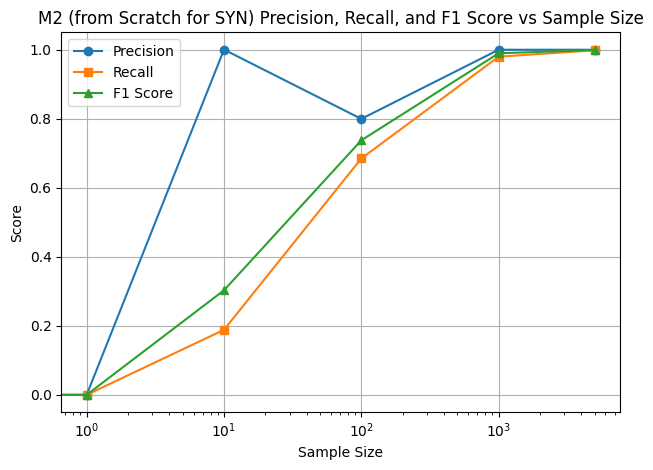

In [19]:
# Visualization
print("F1 Scores:")
for i in range(len(f1_scores)):
    print(f"{f1_scores[i]:.4f} ± {f1_scores_std[i]:.4f}")
    
print("Precisions:")
for i in range(len(precisions)):
    print(f"{precisions[i]:.4f} ± {precisions_std[i]:.4f}")
    
print("Recalls:")
for i in range(len(recalls)):
    print(f"{recalls[i]:.4f} ± {recalls_std[i]:.4f}")
    
x = [0, 1, 10, 100, 1000, 5000]

plt.plot(x, precisions, marker='o', label='Precision')
plt.plot(x, recalls, marker='s', label='Recall')
plt.plot(x, f1_scores, marker='^', label='F1 Score')
plt.xscale('log')
plt.xlabel('Sample Size')
plt.ylabel('Score')
plt.title('M2 (from Scratch for SYN) Precision, Recall, and F1 Score vs Sample Size')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
f1_scores_udp = []
f1_scores_std_udp = []
precisions_udp = []
precisions_std_udp = []
recalls_udp = []
recalls_std_udp = []

f1_scores_udp_http = []
f1_scores_std_udp_http = []
precisions_udp_http = []
precisions_std_udp_http = []
recalls_udp_http = []
recalls_std_udp_http = []

f1_scores_udp_http_syn = []
f1_scores_std_udp_http_syn = []
precisions_udp_http_syn = []
precisions_std_udp_http_syn = []
recalls_udp_http_syn = []
recalls_std_udp_http_syn = []

# Experiment with different number of meta-test samples
for len_meta_test in [1, 10, 100, 1000, 5000]:
    print(f"Running for len_meta_test: {len_meta_test}")
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Shuffle indices for random sampling
    rng = np.random.default_rng(seed=len_meta_test)
    rng.shuffle(benign_index)
    rng.shuffle(udp_index)
    rng.shuffle(train_http_index)
    rng.shuffle(train_syn_index)
    rng.shuffle(test_http_index)
    rng.shuffle(test_syn_index)

    fold_f1_scores_udp = []
    fold_precisions_udp = []
    fold_recalls_udp = []
    
    fold_f1_scores_udp_http = []
    fold_precisions_udp_http = []
    fold_recalls_udp_http = []
    
    fold_f1_scores_udp_http_syn = []
    fold_precisions_udp_http_syn = []
    fold_recalls_udp_http_syn = []

    combined_index = np.concatenate([benign_index, udp_index])
    for fold, (train, test) in enumerate(kf.split(combined_index)):
        # Get indices for each class in train and test
        train_index = combined_index[train]
        test_index = combined_index[test]
        rng.shuffle(train_index)
        rng.shuffle(test_index)
        
        train_benign_index = np.intersect1d(train_index, benign_index)
        train_udp_index = np.intersect1d(train_index, udp_index)
        test_benign_index = np.intersect1d(test_index, benign_index)
        test_udp_index = np.intersect1d(test_index, udp_index)

        # Split into 40%, 30% and 30%    
        len_train_udp_40 = int(0.4 * len(train_udp_index))
        len_train_udp_70 = int(0.7 * len(train_udp_index))
        
        # Split into 40%, 15%, 15%, 15% and 15%    
        len_train_benign_40 = int(0.4 * len(train_benign_index))
        len_train_benign_55 = int(0.55 * len(train_benign_index))
        len_train_benign_70 = int(0.7 * len(train_benign_index))
        len_train_benign_85 = int(0.85 * len(train_benign_index))

        # Initialize model and training
        model = MLP(X_processed.shape[1])
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        #--------------------------------- Training with UDP only ---------------------------------------#
        # Train: 40% UDPFlood + 40% Benign
        udp_train_index = np.concatenate([train_udp_index[:len_train_udp_40], train_benign_index[:len_train_benign_40]])
        x_train = torch.tensor(X_processed[udp_train_index], dtype=torch.float32)
        y_train = torch.tensor(y_processed[udp_train_index], dtype=torch.float32).unsqueeze(1)
        print("UDP: y_train == 0:", (y_train == 0).sum().item(), "y_train == 1:", (y_train == 1).sum().item())

        # Training with UDP only
        for epoch in range(1000):
            loss = normal_train_step(model, x_train, y_train, optimizer)

        # Evaluation with UDP only
        with torch.no_grad():
            udp_test_index = np.concatenate([test_benign_index[:1000], test_udp_index[:1000]])
            x_test = torch.tensor(X_processed[udp_test_index], dtype=torch.float32)
            y_test = torch.tensor(y_processed[udp_test_index], dtype=torch.float32).unsqueeze(1)
            print("UDP: y_test == 0:", (y_test == 0).sum().item(), "y_test == 1:", (y_test == 1).sum().item())

            y_pred = model(x_test).squeeze().round().numpy()
            score = f1_score(y_test.numpy(), y_pred)
            precision = precision_score(y_test.numpy(), y_pred, zero_division=0)
            recall = recall_score(y_test.numpy(), y_pred)

            fold_f1_scores_udp.append(score)
            fold_precisions_udp.append(precision)
            fold_recalls_udp.append(recall)
            

        #--------------------------------- Training with UDP and HTTP ---------------------------------------#
        # Meta-train: 30% UDPFlood + 15% Benign
        udp_http_meta_train_index = np.concatenate([train_udp_index[len_train_udp_40:len_train_udp_70], train_benign_index[len_train_benign_40:len_train_benign_55]])
        x_meta_train = torch.tensor(X_processed[udp_http_meta_train_index], dtype=torch.float32)
        y_meta_train = torch.tensor(y_processed[udp_http_meta_train_index], dtype=torch.float32).unsqueeze(1)
        print("UDP + HTTP: y_meta_train == 0:", (y_meta_train == 0).sum().item(), "y_meta_train == 1:", (y_meta_train == 1).sum().item())

        # Meta-test: len_meta_test samples from HTTPFlood and 15% Benign
        udp_http_meta_test_index = np.concatenate([
            train_http_index[:len_meta_test], 
            train_benign_index[len_train_benign_55:len_train_benign_70]
        ])
        x_meta_test = torch.tensor(X_processed[udp_http_meta_test_index], dtype=torch.float32)
        y_meta_test = torch.tensor(y_processed[udp_http_meta_test_index], dtype=torch.float32).unsqueeze(1)
        print("UDP + HTTP: y_meta_test == 0:", (y_meta_test == 0).sum().item(), "y_meta_test == 1:", (y_meta_test == 1).sum().item())

        for epoch in range(1000):
            loss = meta_train_step(model, x_meta_train, y_meta_train, x_meta_test, y_meta_test, optimizer)
            
        # Evaluation
        with torch.no_grad():
            udp_http_test_index = np.concatenate([test_benign_index[:2000], test_udp_index[:1000], test_http_index[:1000]])
            x_test= torch.tensor(X_processed[udp_http_test_index], dtype=torch.float32)
            y_test = torch.tensor(y_processed[udp_http_test_index], dtype=torch.float32).unsqueeze(1)
            print("UDP + HTTP: y_test == 0:", (y_test == 0).sum().item(), "y_test == 1:", (y_test == 1).sum().item())

            y_pred = model(x_test).squeeze().round().numpy()
            score = f1_score(y_test.numpy(), y_pred)
            precision = precision_score(y_test.numpy(), y_pred, zero_division=0)
            recall = recall_score(y_test.numpy(), y_pred)

            fold_f1_scores_udp_http.append(score)
            fold_precisions_udp_http.append(precision)
            fold_recalls_udp_http.append(recall)


        #--------------------------------- Training with UDP and SYN ---------------------------------------#
        # Meta-train: 30% UDPFlood + 15% Benign
        meta_train_index = np.concatenate([train_udp_index[len_train_udp_70:], train_benign_index[len_train_benign_70:len_train_benign_85]])    
        x_meta_train = torch.tensor(X_processed[meta_train_index], dtype=torch.float32)
        y_meta_train = torch.tensor(y_processed[meta_train_index], dtype=torch.float32).unsqueeze(1)
        print("UDP + HTTP + SYN: y_meta_train == 0:", (y_meta_train == 0).sum().item(), "y_meta_train == 1:", (y_meta_train == 1).sum().item())

        # Meta-test: len_meta_test samples from SYNFlood and 15% Benign
        meta_test_index = np.concatenate([
            train_syn_index[:len_meta_test], 
            train_benign_index[len_train_benign_85:]
        ])
        x_meta_test = torch.tensor(X_processed[meta_test_index], dtype=torch.float32)
        y_meta_test = torch.tensor(y_processed[meta_test_index], dtype=torch.float32).unsqueeze(1)
        print("UDP + HTTP + SYN: y_meta_test == 0:", (y_meta_test == 0).sum().item(), "y_meta_test == 1:", (y_meta_test == 1).sum().item())
        
        # Training
        for epoch in range(1000):
            loss = meta_train_step(model, x_meta_train, y_meta_train, x_meta_test, y_meta_test, optimizer)

        # Evaluation
        with torch.no_grad():
            udp_http_syn_test_index = np.concatenate([test_benign_index[:3000], test_udp_index[:1000], test_http_index[:1000], test_syn_index[:1000]])
            x_test= torch.tensor(X_processed[udp_http_syn_test_index], dtype=torch.float32)
            y_test = torch.tensor(y_processed[udp_http_syn_test_index], dtype=torch.float32).unsqueeze(1)
            print("UDP + HTTP + SYN: y_test == 0:", (y_test == 0).sum().item(), "y_test == 1:", (y_test == 1).sum().item())
            
            y_pred = model(x_test).squeeze().round().numpy()
            score = f1_score(y_test.numpy(), y_pred)
            precision = precision_score(y_test.numpy(), y_pred, zero_division=0)
            recall = recall_score(y_test.numpy(), y_pred)

            fold_f1_scores_udp_http_syn.append(score)
            fold_precisions_udp_http_syn.append(precision)
            fold_recalls_udp_http_syn.append(recall)

    f1_scores_udp.append(np.mean(fold_f1_scores_udp))
    precisions_udp.append(np.mean(fold_precisions_udp))
    recalls_udp.append(np.mean(fold_recalls_udp))
    f1_scores_std_udp.append(np.std(fold_f1_scores_udp))
    precisions_std_udp.append(np.std(fold_precisions_udp))
    recalls_std_udp.append(np.std(fold_recalls_udp))

    f1_scores_udp_http.append(np.mean(fold_f1_scores_udp_http))
    precisions_udp_http.append(np.mean(fold_precisions_udp_http))
    recalls_udp_http.append(np.mean(fold_recalls_udp_http))
    f1_scores_std_udp_http.append(np.std(fold_f1_scores_udp_http))
    precisions_std_udp_http.append(np.std(fold_precisions_udp_http))
    recalls_std_udp_http.append(np.std(fold_recalls_udp_http))

    f1_scores_udp_http_syn.append(np.mean(fold_f1_scores_udp_http_syn))
    precisions_udp_http_syn.append(np.mean(fold_precisions_udp_http_syn))
    recalls_udp_http_syn.append(np.mean(fold_recalls_udp_http_syn))
    f1_scores_std_udp_http_syn.append(np.std(fold_f1_scores_udp_http_syn))
    precisions_std_udp_http_syn.append(np.std(fold_precisions_udp_http_syn))
    recalls_std_udp_http_syn.append(np.std(fold_recalls_udp_http_syn))
    
    print(f"F1 Score (UDP): {f1_scores_udp[-1]:.4f} ± {f1_scores_std_udp[-1]:.4f}")
    print(f"F1 Score (UDP + HTTP): {f1_scores_udp_http[-1]:.4f} ± {f1_scores_std_udp_http[-1]:.4f}")
    print(f"F1 Score (UDP + HTTP + SYN): {f1_scores_udp_http_syn[-1]:.4f} ± {f1_scores_std_udp_http_syn[-1]:.4f}")

Running for len_meta_test: 1
UDP: y_train == 0: 152912 y_train == 1: 146312
UDP: y_test == 0: 1000 y_test == 1: 1000
UDP + HTTP: y_meta_train == 0: 57342 y_meta_train == 1: 109734
UDP + HTTP: y_meta_test == 0: 57342 y_meta_test == 1: 1
UDP + HTTP: y_test == 0: 2000 y_test == 1: 2000
UDP + HTTP + SYN: y_meta_train == 0: 57342 y_meta_train == 1: 109735
UDP + HTTP + SYN: y_meta_test == 0: 57342 y_meta_test == 1: 1
UDP + HTTP + SYN: y_test == 0: 3000 y_test == 1: 3000
UDP: y_train == 0: 152894 y_train == 1: 146330
UDP: y_test == 0: 1000 y_test == 1: 1000
UDP + HTTP: y_meta_train == 0: 57335 y_meta_train == 1: 109748
UDP + HTTP: y_meta_test == 0: 57335 y_meta_test == 1: 1
UDP + HTTP: y_test == 0: 2000 y_test == 1: 2000
UDP + HTTP + SYN: y_meta_train == 0: 57335 y_meta_train == 1: 109748
UDP + HTTP + SYN: y_meta_test == 0: 57336 y_meta_test == 1: 1
UDP + HTTP + SYN: y_test == 0: 3000 y_test == 1: 3000
UDP: y_train == 0: 152903 y_train == 1: 146321
UDP: y_test == 0: 1000 y_test == 1: 1000
UDP

Results for UDPFlood only:
F1 Scores:
1.0000 ± 0.0000
1.0000 ± 0.0000
1.0000 ± 0.0000
1.0000 ± 0.0000
1.0000 ± 0.0000
Precisions:
1.0000 ± 0.0000
1.0000 ± 0.0000
1.0000 ± 0.0000
1.0000 ± 0.0000
1.0000 ± 0.0000
Recalls:
1.0000 ± 0.0000
1.0000 ± 0.0000
1.0000 ± 0.0000
1.0000 ± 0.0000
1.0000 ± 0.0000
Results for UDPFlood + HTTPFlood:
F1 Scores:
0.5732 ± 0.0157
0.6151 ± 0.0323
0.7895 ± 0.0373
0.7622 ± 0.0130
0.7517 ± 0.0057
Precisions:
0.6732 ± 0.0453
0.6168 ± 0.0897
0.6954 ± 0.0576
0.6198 ± 0.0190
0.6032 ± 0.0073
Recalls:
0.5000 ± 0.0000
0.6239 ± 0.0310
0.9165 ± 0.0088
0.9904 ± 0.0043
0.9971 ± 0.0006
Results for UDPFlood + HTTPFlood + SYNFlood:
F1 Scores:
0.4643 ± 0.0309
0.5389 ± 0.0413
0.7549 ± 0.0249
0.7989 ± 0.0346
0.8172 ± 0.0078
Precisions:
1.0000 ± 0.0000
1.0000 ± 0.0000
1.0000 ± 0.0000
1.0000 ± 0.0000
1.0000 ± 0.0000
Recalls:
0.3029 ± 0.0263
0.3699 ± 0.0384
0.6069 ± 0.0319
0.6665 ± 0.0469
0.6910 ± 0.0112


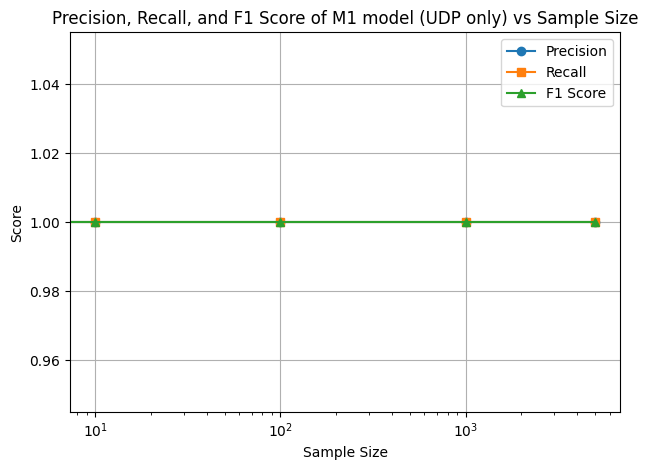

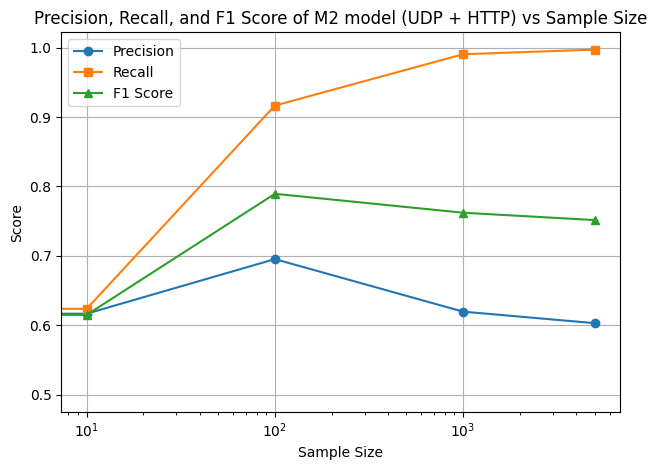

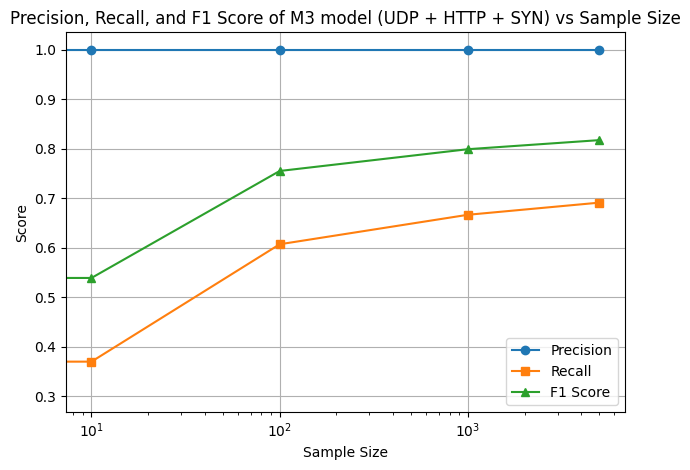

In [17]:
print("Results for UDPFlood only:")
print("F1 Scores:")
for i in range(len(f1_scores_udp)):
    print(f"{f1_scores_udp[i]:.4f} ± {f1_scores_std_udp[i]:.4f}")

print("Precisions:")
for i in range(len(precisions_udp)):
    print(f"{precisions_udp[i]:.4f} ± {precisions_std_udp[i]:.4f}")

print("Recalls:")
for i in range(len(recalls_udp)):
    print(f"{recalls_udp[i]:.4f} ± {recalls_std_udp[i]:.4f}")

print("Results for UDPFlood + HTTPFlood:")
print("F1 Scores:")
for i in range(len(f1_scores_udp_http)):
    print(f"{f1_scores_udp_http[i]:.4f} ± {f1_scores_std_udp_http[i]:.4f}")

print("Precisions:")
for i in range(len(precisions_udp_http)):
    print(f"{precisions_udp_http[i]:.4f} ± {precisions_std_udp_http[i]:.4f}")

print("Recalls:")
for i in range(len(recalls_udp_http)):
    print(f"{recalls_udp_http[i]:.4f} ± {recalls_std_udp_http[i]:.4f}")

print("Results for UDPFlood + HTTPFlood + SYNFlood:")
print("F1 Scores:")
for i in range(len(f1_scores_udp_http_syn)):
    print(f"{f1_scores_udp_http_syn[i]:.4f} ± {f1_scores_std_udp_http_syn[i]:.4f}")

print("Precisions:")
for i in range(len(precisions_udp_http_syn)):
    print(f"{precisions_udp_http_syn[i]:.4f} ± {precisions_std_udp_http_syn[i]:.4f}")

print("Recalls:")
for i in range(len(recalls_udp_http_syn)):
    print(f"{recalls_udp_http_syn[i]:.4f} ± {recalls_std_udp_http_syn[i]:.4f}")

x = [0, 10, 100, 1000, 5000]

plt.plot(x, precisions_udp, marker='o', label='Precision')
plt.plot(x, recalls_udp, marker='s', label='Recall')
plt.plot(x, f1_scores_udp, marker='^', label='F1 Score')
plt.xscale('log')
plt.xlabel('Sample Size')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score of M1 model (UDP only) vs Sample Size')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.plot(x, precisions_udp_http, marker='o', label='Precision')
plt.plot(x, recalls_udp_http, marker='s', label='Recall')
plt.plot(x, f1_scores_udp_http, marker='^', label='F1 Score')
plt.xscale('log')
plt.xlabel('Sample Size')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score of M2 model (UDP + HTTP) vs Sample Size')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.plot(x, precisions_udp_http_syn, marker='o', label='Precision')
plt.plot(x, recalls_udp_http_syn, marker='s', label='Recall')
plt.plot(x, f1_scores_udp_http_syn, marker='^', label='F1 Score')
plt.xscale('log')
plt.xlabel('Sample Size')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score of M3 model (UDP + HTTP + SYN) vs Sample Size')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()